In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
from sqlalchemy import create_engine



DATA_PATH = Path("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = pd.read_csv(DATA_PATH)


print(f"Employee-Attrition: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst look:")
df.head()

Employee-Attrition: 1,470
Columns: 35

First look:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [100]:
# Data shape and column types

#   How many rows and columns you have
#   What data type each column is (number, text, date, etc.)
#   How many non-null (non-blank) values exist per column
#   This immediately reveals missing data problems

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [101]:
# Initial Statistical Summary — Numeric Columns

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [102]:
# Initial Statistical Summary — Numeric Columns - Max Columns 


pd.set_option('display.max_columns', None)
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


OVer18 is not included because it is not a number value.

Employee performance rating was 3 across 25-75% deviation pointing to the majority of ratings are 3, after looking at MIN value I see it is also 3, this tells me the majority of employees are rated 3 with some fours. This tells me my orginal thesis about using performance ratings so determining attrition based of performance might not be valid. We could look at this as a binary sense meaning employees are either satisfactory or above satisfactory. This could be another recommendation stating they could keep valid records of employee performance.

We also see that employee count is the same across all employees, this value is not sueful. We also see standard hours is the same acorss 25% - Max, this value is not useful wither

Drop constants: EmployeeCount, StandardHours, Over18                     

Binary encode Attrition — Yes→1, No→0                                                                                              

Revisit PerformanceRating — consider binary encoding (3 vs 4)

In [103]:
# Create copy of data to work with and keep the Raw data 


df_clean = df.copy()

In [104]:
# Removing unwanted columns 

df_clean = df_clean.drop(columns=["EmployeeCount", "StandardHours", "Over18"])

In [105]:
# Converting Attrition column to Binary (1,0)

df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No" : 0})

df_clean["Attrition"].head(10)

df_clean["Attrition"].unique()



array([1, 0])

In [106]:
# Moving Clean CSV to Clean Folder 

DATA_PATH = Path("../data/clean/WA_Fn-UseC_-HR-Employee-Attrition_clean.csv")

df_clean.to_csv(DATA_PATH)

Took a raw CSV and worked with it in Pandas to clean it and saved clean CSV file in clean folder 

In [107]:
#Creating a SQLite database connection using SQLAlchemy.
# This establishes the path and engine that will be used to load our clean data into a structured database for SQL-based analysis.

db_path = os.path.abspath("../database/ibm_hr.db")
engine = create_engine(f"sqlite:///{db_path}")
print("Connected:", db_path)

Connected: /Users/mitchellsultana/Desktop/stuff/organizer/Data Analytics Projects /ibm-hr-attrition/database/ibm_hr.db


In [108]:
#Data loading into sql 

df_clean.to_sql("employees", engine, if_exists="replace", index=False)
print("Data loaded to database")

Data loaded to database


In [109]:
#SQL Table - Employees

employees = pd.read_sql("SELECT * FROM employees", engine)
print(f"employees: {len(employees)}")
employees

employees: 1470


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,No,17,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,No,15,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Yes,20,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,No,14,3,4,0,17,3,2,9,6,0,8


In [110]:
# Overtime 

import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, OverTime, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY OverTime
"""

q1 = pd.read_sql_query(query, conn)
print(q1)

   employee_count OverTime  attrition_rate
0            1054       No        0.104364
1             416      Yes        0.305288


employees who worked overtime have an attrition rate of 30.5%, compared to 10.4% for employees who did not work overtime. employees who were required to work overtime were three times more likely to leave the company 

In [111]:
# Business Travel

import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT BusinessTravel, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY BusinessTravel
"""

q2 = pd.read_sql_query(query, conn1)
print(q2)

      BusinessTravel  attrition_rate
0         Non-Travel        0.080000
1  Travel_Frequently        0.249097
2      Travel_Rarely        0.149569


Looking at the results we find that IBM employees within the Business Travel Group that Travel_Frequently have an attrition rate of 24.9%, we also see that employees within the BusinessTravel Group that have non_travel status depart the company at a rate of 8%. This shows us that employees that travel frequently are almost 3 times more likely to leave the company.

In [112]:
# Distance From Home 

import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN DistanceFromHome <= 10 THEN 'short'
    WHEN DistanceFromHome <= 20 THEN 'medium'
    WHEN DistanceFromHome <= 29 THEN 'high'
END AS distance_group, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY distance_group
"""

q3 = pd.read_sql_query(query, conn1)
print(q3)

  distance_group  attrition_rate
0           high        0.220588
1         medium        0.200000
2          short        0.140351


Looking at the IBM employee data, we see that employees that have to travel a longer distance from their home to work have an attrition rate of 22.05%, also the medium group is listed as 10-20 miles from work and that resulted in an attrition rate of 20% , lastly we saw employees within the distance_group that had to travel 10 miles or less to work were departing the company at 14.03%. We can conclude that a higher distance to work can contribute to attrition at IBM.

In [113]:
# Number of Trainings Since Last Year

import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN TrainingTimesLastYear <= 2 THEN 'low'
    WHEN TrainingTimesLastYear <= 4 THEN 'medium'
    WHEN TrainingTimesLastYear <= 6 THEN 'high'
END AS training_times, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY training_times
"""

q4 = pd.read_sql_query(query, conn1)
print(q4)

  training_times  attrition_rate
0           high        0.108696
1            low        0.181548
2         medium        0.154723


After looking at the IBM employee data, we see that higher number of trainings since last year results in higher retention. IBM can focus on offering training for their employees to result in less attrition.

Operational recommendation for IBM

I would say IBM could reduce attrition rates among employees by equipping their employees with training so they have the tools they need to successfully do their jobs. They also can be intentional when requiring overtime and business travel to employees because employees are three times more likely to depart when they experience business travel and over time. Lastly when hiring employees IBM should take into consideration the distance a employee has to commute to work because increased distance from work has a strong correlation to attrition.

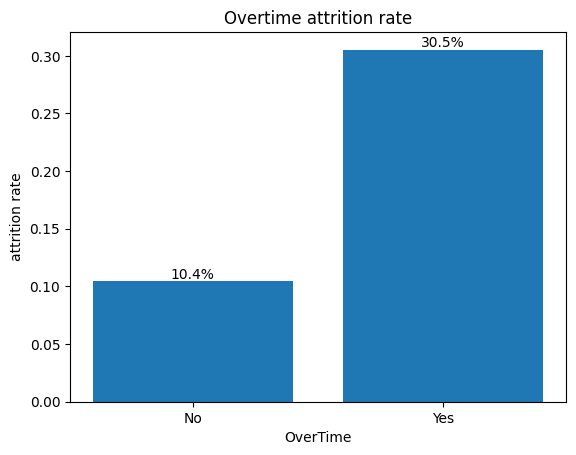

In [114]:
# Overtime Attrition rate 

import matplotlib.pyplot as plt

bars = plt.bar(q1['OverTime'], q1['attrition_rate'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:.1%}', ha='center', va='bottom')
    
plt.title('Overtime attrition rate')
plt.xlabel('OverTime')
plt.ylabel('attrition rate')
plt.show()

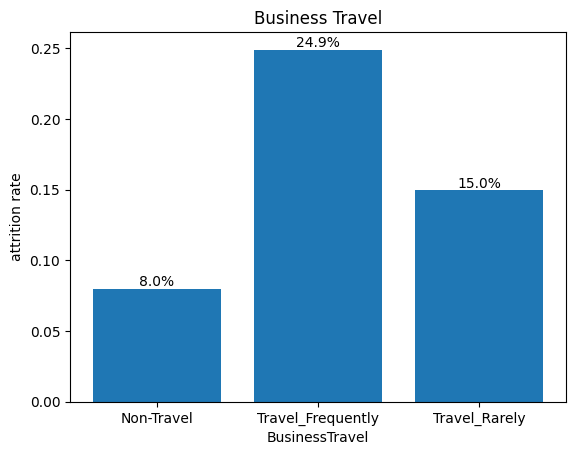

In [115]:

import matplotlib.pyplot as plt

bars = plt.bar(q2['BusinessTravel'], q2['attrition_rate'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:.1%}', ha='center', va='bottom')
    
plt.title('Business Travel')
plt.xlabel('BusinessTravel')
plt.ylabel('attrition rate')
plt.show()
    


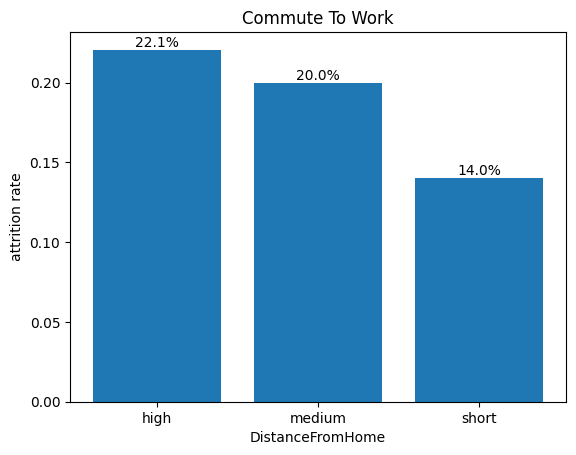

In [116]:

import matplotlib.pyplot as plt

bars = plt.bar(q3['distance_group'], q3['attrition_rate'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:.1%}', ha='center', va='bottom')
    
plt.title('Commute To Work')
plt.xlabel('DistanceFromHome')
plt.ylabel('attrition rate')
plt.show()




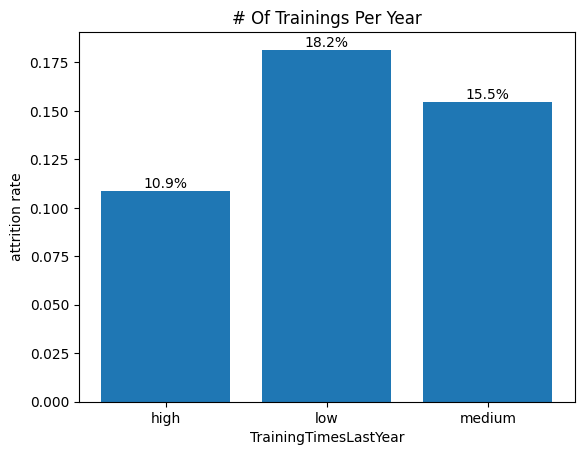

In [117]:


import matplotlib.pyplot as plt

bars = plt.bar(q4['training_times'], q4['attrition_rate'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:.1%}', ha='center', va='bottom')
    
plt.title('# Of Trainings Per Year')
plt.xlabel('TrainingTimesLastYear')
plt.ylabel('attrition rate')
plt.show()



Do employees who are promoted more frequently and stay at IBM longer have lower attrition?

Your variables are all numeric — YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, TotalWorkingYears.
Same approach as DistanceFromHome — you need CASE WHEN buckets.


In [118]:
# Number of Trainings Since Last Year

import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN YearsSinceLastPromotion <= 5 THEN '0-5 yrs'
    WHEN YearsSinceLastPromotion <= 10 THEN '6-10 yrs'
    WHEN YearsSinceLastPromotion <= 15 THEN '11-15 yrs'
END AS YearsSincePromotion, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY YearsSincePromotion
ORDER BY CASE YearsSincePromotion
    WHEN '0-5 yrs' THEN 1
    WHEN '6-10 yrs' THEN 2
    WHEN '11-15 yrs' THEN 3
END
"""

q5 = pd.read_sql_query(query, conn1)
print(q5)

  YearsSincePromotion  attrition_rate
0             0-5 yrs        0.160956
1            6-10 yrs        0.181208
2           11-15 yrs        0.121212


Do employees who are promoted more frequently and stay at IBM longer have lower attrition?


Finding
After analyzing the IBM employee data, we find that the relationship between years since last promotion and attrition is non-linear. Employees in the 0–5 year range show an attrition rate of 16.1%, rising to 18.1% in the 6–10 year range, then dropping to 12.1% for employees who have gone 11–15 years without a promotion.

Interpretation
The peak attrition in the 6–10 year window suggests a promotion expectation threshold and employees who have waited long enough to expect career advancement but have not received it appear more likely to leave. The drop in the 11–15 year group likely reflects survivorship bias, where employees who were dissatisfied with their growth trajectory had already departed, leaving a self-selected group of tenured employees who are comfortable in their roles.

Data Limitation
This dataset does not distinguish between voluntary resignation, involuntary termination, and retirement. The attrition patterns observed may reflect multiple causes and should be interpreted with caution.

Operational Recommendation
IBM should capture attrition type at the point of separation — voluntary resignation, involuntary termination, or retirement — to enable more precise analysis of what is driving employee departures.
IBM should examine promotion cadence in the 6–10 year employee window as a potential lever for improving retention.


In [119]:
# Number of Trainings Since Last Year

import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN YearsAtCompany <= 10 THEN '0-10 yrs'
    WHEN YearsAtCompany <= 20 THEN '11-20 yrs'
    WHEN YearsAtCompany <= 30 THEN '21-30 yrs'
    WHEN YearsAtCompany <= 40 THEN '31-40 yrs'
END AS YearsAtIBM, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY YearsAtIBM
ORDER BY CASE YearsAtIBM
    WHEN '0-10 yrs' THEN 1
    WHEN '11-20 yrs' THEN 2
    WHEN '21-30 yrs' THEN 3
    WHEN '31-40 yrs' THEN 4
END
"""

q6 = pd.read_sql_query(query, conn1)
print(q6)

  YearsAtIBM  attrition_rate
0   0-10 yrs        0.177288
1  11-20 yrs        0.066667
2  21-30 yrs        0.080000
3  31-40 yrs        0.250000


After analyzing the data I feel we can see the highest risk for attrition is in 1-10 years at IBM anad then 31-40 years but I feel like a safe assumption is that a large number of employees in this group are leaving the company becuase of retirement assuming most people retire around at ages 60-65.

In [120]:


import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN YearsInCurrentRole <= 6 THEN '0-6 yrs'
    WHEN YearsInCurrentRole <= 12 THEN '7-12 yrs'
    WHEN YearsInCurrentRole <= 18 THEN '13-18 yrs'
END AS YearsInRole, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY YearsInRole
ORDER BY CASE YearsInRole
    WHEN '0-6 yrs' THEN 1
    WHEN '7-12 yrs' THEN 2
    WHEN '13-18 yrs' THEN 3
END
"""

q7 = pd.read_sql_query(query, conn1)
print(q7)

  YearsInRole  attrition_rate
0     0-6 yrs        0.188832
1    7-12 yrs        0.107062
2   13-18 yrs        0.086957


It looks like attrition drops as years in role increase, which fits a survivorship bias story—people who weren’t happy already left, leaving a more stable group behind. It’s also probably tied to life stage, where earlier employees are exploring and moving around, while later ones value stability more. We do see a contradiction between this analysis of YearInRole and PromotionsSinceLastYear which might be explained by by the reasons listted above like life stages and survivorship

In [121]:



conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN YearsWithCurrManager <= 6 THEN '0-6 yrs'
    WHEN YearsWithCurrManager <= 11 THEN '7-11 yrs'
    WHEN YearsWithCurrManager <= 17 THEN '12-17 yrs'
END AS YearsWithManager, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY YearsWithManager
ORDER BY CASE YearsWithManager
    WHEN '0-6 yrs' THEN 1
    WHEN '7-11 yrs' THEN 2
    WHEN '12-17 yrs' THEN 3
END
"""

q8 = pd.read_sql_query(query, conn1)
print(q8)

  YearsWithManager  attrition_rate
0          0-6 yrs        0.187182
1         7-11 yrs        0.116972
2        12-17 yrs        0.039216


We see in this analysis that the longer amount of time a emplyee spends with their manager the smaller rate of attrition we see within that group. What we dont know is if this is due to them growing in their career, having a mentor, having someone they know and trust, growing with their team, these are all viable reasons that would explain this. This also could be related to survivorship or life stages. We will search for more data to add more context to this analysis.

In [122]:



import sqlite3
conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN TotalWorkingYears <= 10 THEN '0-10 yrs'
    WHEN TotalWorkingYears <= 20 THEN '11-20 yrs'
    WHEN TotalWorkingYears <= 30 THEN '21-30 yrs'
    WHEN TotalWorkingYears <= 40 THEN '31-40 yrs'
END AS YearsWorking, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY YearsWorking
ORDER BY CASE YearsWorking
    WHEN '0-10 yrs' THEN 1
    WHEN '11-20 yrs' THEN 2
    WHEN '21-30 yrs' THEN 3
    WHEN '31-40 yrs' THEN 4
END
"""

q9 = pd.read_sql_query(query, conn1)
print(q9)

  YearsWorking  attrition_rate
0     0-10 yrs        0.197183
1    11-20 yrs        0.114706
2    21-30 yrs        0.068323
3    31-40 yrs        0.108696


During our analysis of TotalYearsWorking, we see that the highest rate of attrition happens in 0-10 years group which aligns with our life stages therory that we will see more people depart the company becasue they are younger, still building their career, more likely to change employers, searching for the right job. We do also see the rate drop down throughout the groups until we get to the last group 31-40 which would align with our therory that this maybe due to employees reaching the retirment age range since they have been working 31-40 years.

In [123]:
import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, PerformanceRating, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY PerformanceRating
"""

q10 = pd.read_sql_query(query, conn)
print(q10)

   employee_count  PerformanceRating  attrition_rate
0            1244                  3        0.160772
1             226                  4        0.163717


Finding
Performance rating has no meaningful effect on attrition in this dataset — employees rated 3 and 4 depart at nearly identical rates of 16.1% and 16.4% respectively.

Data Limitation
The rating floor of 3 across all 1,470 employees suggests the performance review system lacks calibration. Either ratings 1 and 2 are never assigned, or the data was filtered upstream — making performance rating an unreliable variable for attrition analysis.

Operational Recommendation
IBM should audit its performance review process. If managers are avoiding low ratings, the company loses a critical signal for identifying at-risk employees and addressing underperformance before it leads to attrition. More accurate performance data would meaningfully improve attrition modeling.

In [124]:
import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, RelationshipSatisfaction, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY RelationshipSatisfaction
"""

q11 = pd.read_sql_query(query, conn)
print(q11)

   employee_count  RelationshipSatisfaction  attrition_rate
0             276                         1        0.206522
1             303                         2        0.148515
2             459                         3        0.154684
3             432                         4        0.148148


"Does lower employee satisfaction result in higher attrition?

Within this dataset of 1,470 IBM employees, Do we see employee’s with higher “employee satisfaction” scores above 2 have less attrition, taking into account relationship satisfaction, job satisfaction and work life balance all on a scale of 1-4? If this is true we would suggest IBM to focus on working with employees to find out what matters to their employees through a survey and having HR and mangers structuring work environment to match their employees values."

From this analysis we see a direct correlation between low relationship satisfaction scores and higher rates of attrition. If we look deeper we see that the attrition rate is pretty flat for scores 2-4 but than spikes when the score gets down to a 1 to a 20.6% rate of attrition. The data shows us that when someone has low relationship satisfaction scores at work it effects their "Employee Satisfaction" leading to higher attrition rates.

In [125]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, JobSatisfaction, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY JobSatisfaction
"""

q12 = pd.read_sql_query(query, conn)
print(q12)

   employee_count  JobSatisfaction  attrition_rate
0             289                1        0.228374
1             280                2        0.164286
2             442                3        0.165158
3             459                4        0.113290


After analying the data we see a much greater correlation between job satisfaction scores and attrition rate than we did with employee satisfaction. We see that job satisfaction score of 4 have only a 11.3% attrition rate compared to scores of 1 which result on 22.8% rate of attrition. We also see that scores of both 2 and 3 result in almost identical rates of attrition 16.4% for scores of  and 16.5% for scores of 3. We can see that when people dont feel satisfied with their job or a score of 1 they are almost double as likely to leave IBM compared to scores of 4.I did notice that employee groups that scored 3 & 4 were roughly twice the amount of employees that scored 1 & 2, which I think is a useful data point.

In [126]:



import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, EnvironmentSatisfaction, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY EnvironmentSatisfaction
"""

q13 = pd.read_sql_query(query, conn)
print(q13)


   employee_count  EnvironmentSatisfaction  attrition_rate
0             284                        1        0.253521
1             287                        2        0.149826
2             453                        3        0.136865
3             446                        4        0.134529


After analysis we see that IBM employees that have a greater rate of environment satisfaction have a lower rate of attrition versus employees that have lower environment scores like 1 where we see a 25.3% rate of attrition. This points to our overall hypothesis that higher employee satisfaction results in lower attrition and we can see an aspect of that here, employee that have environment satisfaction score or 1 are almost twice as likely of attrition compared to employees with rating of 4. We also see that there is a drop off in attrition rate from 1 & 2 to 3 & 4 which suggests IBM should focus on trying to push employees in 1 & 2 to 3 & 4 would result in high retnention.

In [127]:




import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, WorkLifeBalance, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY WorkLifeBalance
"""

q14 = pd.read_sql_query(query, conn)
print(q14)

   employee_count  WorkLifeBalance  attrition_rate
0              80                1        0.312500
1             344                2        0.168605
2             893                3        0.142217
3             153                4        0.176471


review 

After analysis we see that IBM employees that have a lower rating of WorkLifeBalance have a higher rate of attrition versus employees that have higher WorkLifeBalance scores like 1 where we see a 32.2% rate of attrition. This points to our overall finding that higher employee WorkLifeBalance ratings have lower attrition and we can see an aspect of that here, employee that have WorkLifeBalance score like 1 are almost twice as likely of attrition compared to employees with rating of 4. We recommend that IBM keeps a high focus on WorkLifeBalance for their employees, we also see the employee count of groups with ratings of 3 & 2 equate to 1237 employees compared to 153 employees with a rating of 4 and 80 employees with a rating of 1, showing us there is room for improvement. We do see IBM employees with scores of 4 leave slightly higher rate than employees with ratings of 2 & 3, which is interesting and warrants some more research.

In [128]:



import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, JobInvolvement, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY JobInvolvement
"""

q15 = pd.read_sql_query(query, conn)
print(q15)

   employee_count  JobInvolvement  attrition_rate
0              83               1        0.337349
1             375               2        0.189333
2             868               3        0.144009
3             144               4        0.090278


review 

After analysis we see that IBM employees that have a lower rating of JobInvolvement have a higher rate of attrition versus employees that have higher JobInvolvement scores like 1 where we see a 33.7% rate of attrition. This points to our overall finding that higher employee JobInvolvement ratings have lower attrition and we can see an aspect of that here, employee that have JobInvolvement score like 1 are almost three times as likely of attrition compared to employees with rating of 4. We can see that IBM employees with a high rating on JobInvolvement value their jobs, IBM should focus on ensuring these employees feel connected to their jobs an continue to see the benefit of the work they do for IBM. Similarly to WorkLifeBalance we see there is room for improvement in rising ratings of employees and trying to achieve more ratings of 4 across IBM employees.

Do employees with lower readiness result in higher attrition?

Within this dataset of 1,470 IBM employees, do IBM employees with lower readiness increase the chance of attrition, readiness defined as lower than 2 education score. If this is true, IBM should focus on hiring employees that have a education number higher than 2 or start to require training.




In [129]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, Education, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY Education
"""

q16 = pd.read_sql_query(query, conn)
print(q16)

   employee_count  Education  attrition_rate
0             170          1        0.182353
1             282          2        0.156028
2             572          3        0.173077
3             398          4        0.145729
4              48          5        0.104167


Review

After analysis we see that education level does not strongly predict attrition contrary to our initial prediction. This data shows us that IBM should focus resources somewhere else where they might get more of a return for their efforts.

In [130]:



import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, EducationField, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY EducationField
"""

q17 = pd.read_sql_query(query, conn)
print(q17)

   employee_count    EducationField  attrition_rate
0              27   Human Resources        0.259259
1             606     Life Sciences        0.146865
2             159         Marketing        0.220126
3             464           Medical        0.135776
4              82             Other        0.134146
5             132  Technical Degree        0.242424


After analysis we see that Human Resources at 25.9% and Technical Degree at 24.2% are worth flagging because of their high rates of attrition. This warrants further research and analysis to find why these two education fields are elevated and why specifically a Technical degree would not have lower attrition rates.

q

In [131]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, MaritalStatus, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY MaritalStatus
"""

q18 = pd.read_sql_query(query, conn)
print(q18)

   employee_count MaritalStatus  attrition_rate
0             327      Divorced        0.100917
1             673       Married        0.124814
2             470        Single        0.255319


review

After analysis we see that IBM employees that belong to the single group have the highest attrition, over double married people. We also see that divorced employees have the lowest rate of attrition, this supports our earlier findings that this is attributed to different life stages that lead to attrition. While this dataset does not directly measure life stage factors, the pattern is consistent with broader workforce research suggesting that employees with greater financial and family obligations tend to exhibit lower voluntary turnover.

In [132]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, JobLevel, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY JobLevel
"""

q19 = pd.read_sql_query(query, conn)
print(q19)

   employee_count  JobLevel  attrition_rate
0             543         1        0.263352
1             534         2        0.097378
2             218         3        0.146789
3             106         4        0.047170
4              69         5        0.072464


After analysis we see that IBM employees with low JobLevel like 1 have high turnover coming in at 26.3% because people are younger and there is lower cost to job switching, they are also first to go when layoffs hit and terminations within IBM, When you move up the corporate ladder people have invested more effort and time into their jobs and IBM relies on them more than a level one. At level 2 people are trying to move up the corporate ladder, you can also see there is a small jump in attrition at level 3 and I think this could be when people start to leverage their position to find another job or make a vertical move. This jump we see at JobLevel 3 could also be similar to what we found in YearsSinceLastPromotion we had the same inflection point where people that expected a promotion and did not receive one were willing to leave the company, also with this sharp drop off at 4 going down to 4.7%, this points to being at the managerial level where people have gotten those promotions and are invested in their jobs and IBM.

In [133]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, Department, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY Department
"""

q20 = pd.read_sql_query(query, conn)
print(q20)

   employee_count              Department  attrition_rate
0              63         Human Resources        0.190476
1             961  Research & Development        0.138398
2             446                   Sales        0.206278


After analysis we see that IBM employees with roles in Research & Development department at 13.8% being the lowest makes sense for IBM specifically, their core business is technology and innovation. Those employees are harder to replace, more specialized, and likely better compensated. Sales department at 20.6% is consistent with what we already found high business travel, overtime, performance pressure. We've  seen this pattern across multiple variables now throughout this analysis. Sales-adjacent roles keep showing up as high attrition. 

In [134]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, JobRole, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY JobRole
"""

q21 = pd.read_sql_query(query, conn)
print(q21)

   employee_count                    JobRole  attrition_rate
0             131  Healthcare Representative        0.068702
1              52            Human Resources        0.230769
2             259      Laboratory Technician        0.239382
3             102                    Manager        0.049020
4             145     Manufacturing Director        0.068966
5              80          Research Director        0.025000
6             292         Research Scientist        0.160959
7             326            Sales Executive        0.174847
8              83       Sales Representative        0.397590


After this analysis we see that Director and Manager roles have the lowest attrition rate which aligns with our department analysis point to IBM valuing Research & Development department and resulting in less attrition there. We see again sales has the highest attrition of 39.7%, the highest we have seen overall throughout our analysis, which largely across businesses in America sales roles high attrition rates. It is interesting that our second highest attrition rate is Laboratory Technician, I wonder if this has a connection to R&D having a cyclical nature and their demand for these roles are constantly changing.

In [135]:


import sqlite3
conn = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT COUNT(*) AS employee_count, NumCompaniesWorked, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY NumCompaniesWorked
"""

q22 = pd.read_sql_query(query, conn)
print(q22)

   employee_count  NumCompaniesWorked  attrition_rate
0             197                   0        0.116751
1             521                   1        0.188100
2             146                   2        0.109589
3             159                   3        0.100629
4             139                   4        0.122302
5              63                   5        0.253968
6              70                   6        0.228571
7              74                   7        0.229730
8              49                   8        0.122449
9              52                   9        0.230769



After this analysis we see that NumCompaniesWorked matches our theory that the more companies a employee has worked at increases their attrition rate, there is a Outlier at 8 companies but the employee count for this group is low at 49 employees so we need more research or data on this to have a clearer understanding of what this means. IBM should use job mobility history as a signal when identifying employees who are long-term retention risks and prioritize accordingly.

In [136]:




conn1 = sqlite3.connect('../database/ibm_hr.db')

query = """
SELECT CASE 
    WHEN Age <= 20 THEN '0-20 yrs'
    WHEN Age <= 40 THEN '21-40 yrs'
    WHEN Age <= 60 THEN '41-60 yrs'
END AS EmployeeAge, AVG(Attrition) AS attrition_rate
FROM employees
GROUP BY EmployeeAge
ORDER BY CASE EmployeeAge
    WHEN '0-20 yrs' THEN 1
    WHEN '21-40 yrs' THEN 2
    WHEN '41-60 yrs' THEN 3
END
"""

q23 = pd.read_sql_query(query, conn1)
print(q23)

  EmployeeAge  attrition_rate
0    0-20 yrs        0.571429
1   21-40 yrs        0.172979
2   41-60 yrs        0.111828


After analysis of this data we see a confirmation that as IBM employees get older the attrition rate drops off steeply. This relates back to our life stages theory that as people get older and move through stages of life such as getting married, having children, moving towards retirement they have less of an appetite for risk and moving jobs, companies and careers.